<a href="https://colab.research.google.com/github/ShashikanthKungulwar/CV_practice/blob/main/mnist_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor,Compose,Normalize
from torch.utils.data import DataLoader
import torch.nn as nn

In [2]:
transform = Compose(
    [ToTensor(),
    Normalize(
      (0.1307,),
      (0.3081,)
    )]
)

In [3]:
train_data = MNIST(root="/data",train=True,download=True,transform=transform)
test_data = MNIST(root="/data",train=False,download=True,transform=transform)


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.41MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.32MB/s]


In [4]:
traindata_loader = DataLoader(train_data,batch_size=64,shuffle = True)
testdata_loader  = DataLoader(test_data,batch_size=1000,shuffle=False)

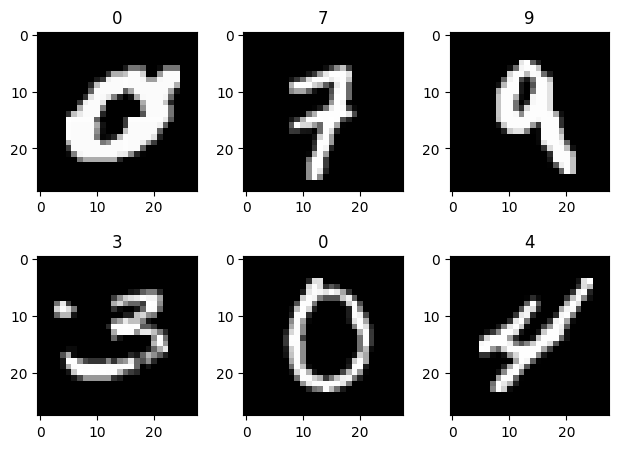

In [5]:
import matplotlib.pyplot as plt

examples = enumerate(traindata_loader)
batch,(x_example,y_example) = next(examples)
fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(x_example[i].squeeze(),cmap="gray")
  plt.title(f"{y_example[i]}")

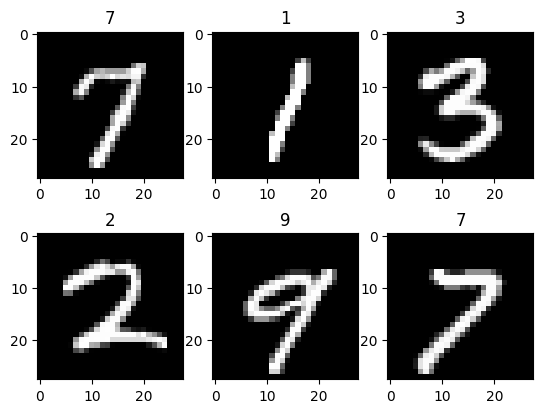

In [6]:
import matplotlib.pyplot as plt

examples = enumerate(traindata_loader)
batch,(x_example,y_example) = next(examples)
fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  # plt.tight_layout()
  plt.imshow(x_example[i].squeeze(),cmap="gray")
  plt.title(f"{y_example[i]}")

In [5]:
from torch.nn import Conv2d,MaxPool2d,Flatten,Linear,Sequential,ReLU,Dropout

In [6]:
class NNModel(nn.Module):
  def __init__(self,input_size,num_classes):
    super(NNModel,self).__init__()
    self.num_classes = num_classes
    self.input_size = input_size

    self.feature_extractor = Sequential(
        Conv2d(out_channels=64,kernel_size =(3,3),in_channels=1),
        ReLU(),
        MaxPool2d(kernel_size=(2,2)),


        Conv2d(out_channels = 128,kernel_size = (3,3),in_channels=64),
        ReLU(),
        MaxPool2d(kernel_size = 2),

        Conv2d(out_channels = 128,kernel_size = (3,3),in_channels=128),
        ReLU(),
        MaxPool2d(kernel_size = (2,2)),
        Dropout(p=0.25),

    )

    self.flatten = Flatten()
    self.classifier = Sequential(
        Linear(in_features =128,out_features=128),
        ReLU(),
        Dropout(p=0.5),
        Linear(in_features=128,out_features=num_classes)
    )
  def forward(self,x):
    # print(x.shape)
    x = self.feature_extractor(x)
    # print(x.shape)
    x = self.flatten(x)
    # here using nn.Flatten so no need to mention axis seperately but remeber this while using other methods of flattening
    # print(x.shape)
    logits = self.classifier(x)
    return logits

In [7]:
model = NNModel(
    input_size = (1,28,28),
    num_classes = 10
)

In [8]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lr=1e-3,betas=(0.9,0.999),eps = 1e-8,params=model.parameters())

In [9]:
device  = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [10]:
model = model.to(device)


In [11]:
epochs = 5

for epoch in range(epochs):
  model.train()
  print(f"epoch: {epoch+1}------------------------------------------------------------------------")
  correct = 0
  total = 0
  for batch,(x_train,y_train) in enumerate(traindata_loader):

    # print(x_train.shape)
    x_train = x_train.to(device)
    y_train = y_train.to(device)
    y_pred = model(x_train)

    total += len(y_train)
    correct += (torch.argmax(y_pred,axis =-1) ==  y_train).sum().item()


    loss = loss_fn(y_pred,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if(batch%100 == 0):
        print(f"batch: {batch}-----> loss {loss.item()}")

  print(f" train accuracy: {correct/total}")
  print("----------------------------------------------------------------------------------------")

  model.eval()
  correct = 0
  total = 0
  # total_loss1 = 0
  total_loss2 = 0
  with torch.no_grad():
    for batch,(x_test,y_test) in enumerate(testdata_loader):
      x_test = x_test.to(device)
      y_test = y_test.to(device)

      y_pred = model(x_test)
      total += len(y_test)
      correct += (torch.argmax(y_pred,axis = -1) == y_test).sum().item()
      loss = loss_fn(y_pred,y_test)
      # total_loss1 += loss.item()
      total_loss2 += len(y_test)*(loss.item())
    print(f"test accuracy: {correct/total}")
    # print(f"total loss1: {total_loss1}")
    print(f"total loss2: {total_loss2/total}")
  print("----------------------------------------------------------------------------------------")



epoch: 1------------------------------------------------------------------------
batch: 0-----> loss 2.3039772510528564
batch: 100-----> loss 0.3962714970111847
batch: 200-----> loss 0.28011974692344666
batch: 300-----> loss 0.3110085129737854
batch: 400-----> loss 0.32860395312309265
batch: 500-----> loss 0.08217918127775192
batch: 600-----> loss 0.21048827469348907
batch: 700-----> loss 0.14900827407836914
batch: 800-----> loss 0.18838149309158325
batch: 900-----> loss 0.13957417011260986
 train accuracy: 0.9039166666666667
----------------------------------------------------------------------------------------
test accuracy: 0.9813
total loss2: 0.06296817008405924
----------------------------------------------------------------------------------------
epoch: 2------------------------------------------------------------------------
batch: 0-----> loss 0.034389909356832504
batch: 100-----> loss 0.19471442699432373
batch: 200-----> loss 0.20512382686138153
batch: 300-----> loss 0.09840

In [12]:
for batch,(x_test,y_test) in enumerate(testdata_loader):

  x_examples = x_test[:10]
  x_examples = x_examples.to(device)
  model.eval()
  with torch.no_grad():
    y_examples = model(x_examples)
  break

In [13]:
x_examples

tensor([[[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],


        [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],


        [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.424

In [14]:
y_examples

tensor([[-10.7733,  -3.2051,  -0.7635,  -2.9450,  -7.7051, -10.1766, -23.6250,
          13.8064,  -9.5290,  -3.9573],
        [ -4.2201,  -5.5347,  14.9505,  -6.9671,  -8.2867, -17.4092,  -6.8500,
          -2.3205,  -4.8247, -13.0888],
        [ -8.0074,  10.6627,  -4.7893,  -7.3825,  -4.4837,  -6.4942,  -9.4093,
          -4.3464,  -6.4370,  -7.8709],
        [ 11.8012, -14.4258,  -6.1718, -13.4909,  -6.7589,  -8.2847,  -2.9252,
          -7.5532,  -5.1222,  -3.7304],
        [ -7.4912,  -7.6718,  -8.4368, -17.5346,  16.1377,  -9.5955,  -6.0250,
          -8.5681,  -3.3117,   2.2705],
        [ -9.1219,  12.3851,  -5.9686,  -8.9227,  -5.0815,  -7.6063, -10.8431,
          -5.4433,  -7.5172,  -8.9089],
        [-10.2772,  -8.8887,  -8.9606, -15.2107,  14.6341,  -9.7516, -10.7485,
          -5.6754,  -0.7530,   4.0290],
        [ -4.0969,  -7.3692,  -4.8381,  -2.8196,   0.3059,  -0.8976,  -9.2326,
          -2.3570,  -1.2935,   6.6609],
        [ -2.4377,  -6.9701,  -4.0789,  -5.1961,

In [15]:
y_examples =  y_examples.cpu()
y_examples = torch.argmax(y_examples,dim =1)

In [16]:
y_examples

tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])

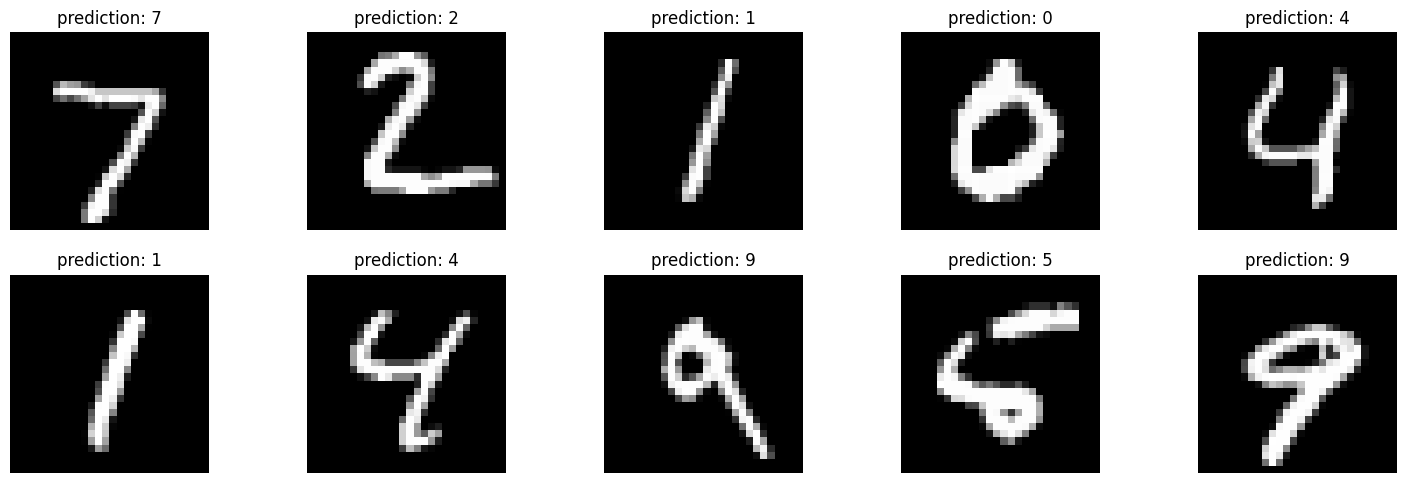

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,5,figsize=(15,5))
fig.tight_layout()

for i in range(10):
  ax = axes[i//5,i%5]
  ax.imshow(x_examples[i].cpu().numpy().squeeze(),cmap="gray")
  ax.set_title(f"prediction: {y_examples[i]}")
  ax.axis("off")

In [18]:
!pip install torchsummary

In [19]:
from torchsummary import summary
summary(model,(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 26, 26]             640
              ReLU-2           [-1, 64, 26, 26]               0
         MaxPool2d-3           [-1, 64, 13, 13]               0
            Conv2d-4          [-1, 128, 11, 11]          73,856
              ReLU-5          [-1, 128, 11, 11]               0
         MaxPool2d-6            [-1, 128, 5, 5]               0
            Conv2d-7            [-1, 128, 3, 3]         147,584
              ReLU-8            [-1, 128, 3, 3]               0
         MaxPool2d-9            [-1, 128, 1, 1]               0
          Dropout-10            [-1, 128, 1, 1]               0
          Flatten-11                  [-1, 128]               0
           Linear-12                  [-1, 128]          16,512
             ReLU-13                  [-1, 128]               0
          Dropout-14                  [

In [20]:
torch.save(model.state_dict(),"model.pth")

In [21]:
model2 = NNModel(1,10).to(device)
model2.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

In [22]:
for batch,(x_test,y_test) in enumerate(testdata_loader):

  x_examples = x_test[:10]
  x_examples = x_examples.to(device)
  model2.eval()
  with torch.no_grad():
    y_examples = model2(x_examples)
  break

In [24]:
y_examples =  y_examples.cpu()
y_examples = torch.argmax(y_examples,dim =1)

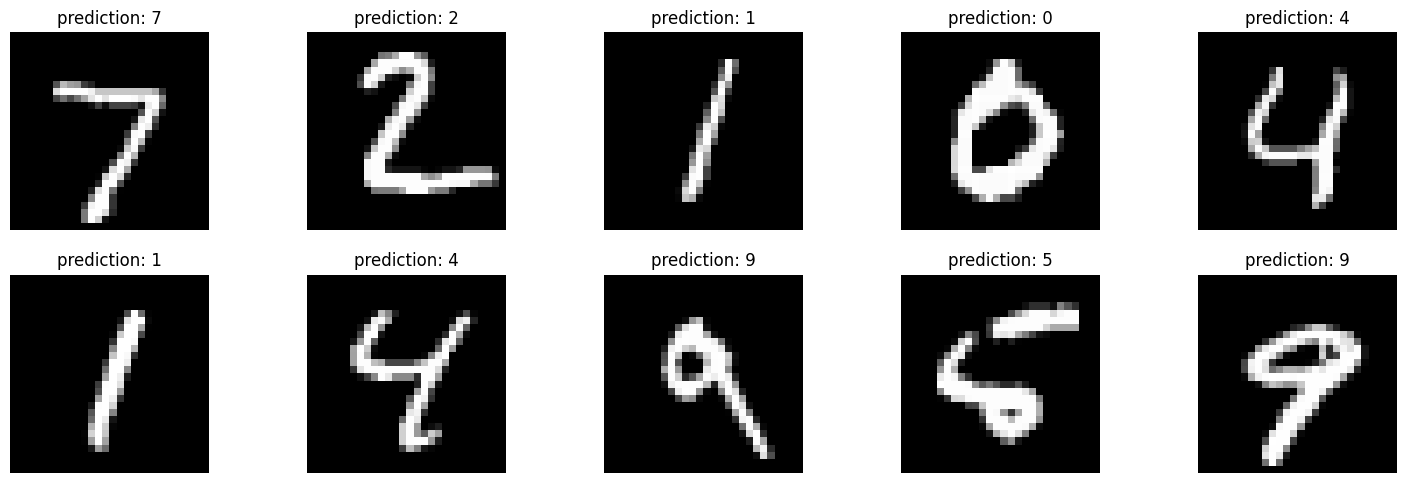

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,5,figsize=(15,5))
fig.tight_layout()

for i in range(10):
  ax = axes[i//5,i%5]
  ax.imshow(x_examples[i].cpu().numpy().squeeze(),cmap="gray")
  ax.set_title(f"prediction: {y_examples[i]}")
  ax.axis("off")